In [1]:
from tripodpy import Simulation
import numpy as np 
import csv
import matplotlib.pyplot as plt
import dustpy.constants as c

In [2]:
sim = Simulation()

In [3]:
sim.initialize()

In [4]:
list_t = []
list_ts = []
def updater_t(sim):
    list_t.append(sim.t)
    list_ts.append(sim.t.prevstepsize)

sim.star.M.updater = updater_t

In [5]:

dir(sim.t)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '

In [6]:

with open("test_sim.csv", "w", newline="") as f:
    writer = csv.writer(f)


    for row in zip(sim.grid.r,sim.grid.OmegaK,sim.gas.Sigma,sim.gas.cs,sim.gas.Hp,sim.gas.T,sim.gas.mu,sim.gas.mfp,sim.gas.eta,sim.gas.P):
        writer.writerow(row)

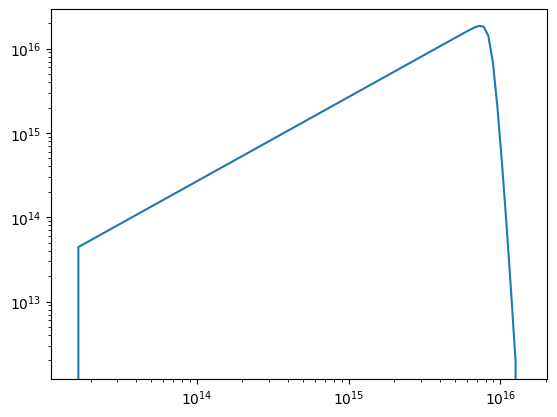

In [7]:
plt.figure()
plt.loglog(sim.grid.r,sim.dust.D[:,2])

In [8]:
sim.dust.D[:4,2]

[0.00000000e+00 4.42816271e+13 4.74486183e+13 5.08421105e+13]

In [9]:
sim.t.snapshots = [36937.52348959519*c.year]#,1e5*c.year]
sim.t.snapshots = [1e5*c.year]
sim.gas.nu = 0e0 
sim.gas.nu.updater = None

In [10]:
sim.writer.overwrite = True
sim.run()


tripodpy v1.0.0

Writing file data/data0000.hdf5
Writing dump file data/frame.dmp
Execution time: 0:00:09


In [11]:
sim.t/c.year

100000.0

In [12]:
sim.grid.ri[-1]/c.au

np.float64(999.999999999997)

In [13]:
sim.ini

namespace(dust=namespace(aIniMax=0.0001,
                         allowDriftingParticles=False,
                         d2gRatio=0.01,
                         distExp=-3.5,
                         rhoMonomer=1.67,
                         vFrag=100.0),
          gas=namespace(alpha=0.001,
                        Mdisk=9.942049353490256e+31,
                        mu=3.847030424486999e-24,
                        SigmaExp=-1.0,
                        SigmaRc=897587224200000.0),
          grid=namespace(mmin=1e-12,
                         Nr=100,
                         rmin=14959787070000.0,
                         rmax=1.495978707e+16),
          star=namespace(M=1.988409870698051e+33, R=139140000000.0, T=5772.0))

In [14]:
sim.dust.s.min

[5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.22875516e-05 5.22875516e-05 5.22875516e-05
 5.22875516e-05 5.228755

In [53]:
import pandas as pd

df = pd.read_csv("tri_0080.outputdat", sep=r"\s+", header=None)

df2 = pd.read_csv("tri_0093.outputdat", sep=r"\s+", header=None)

In [54]:
df2[6][0]/c.year

np.float64(100014.68626614909)

In [55]:
sim.t/c.year

100000.0

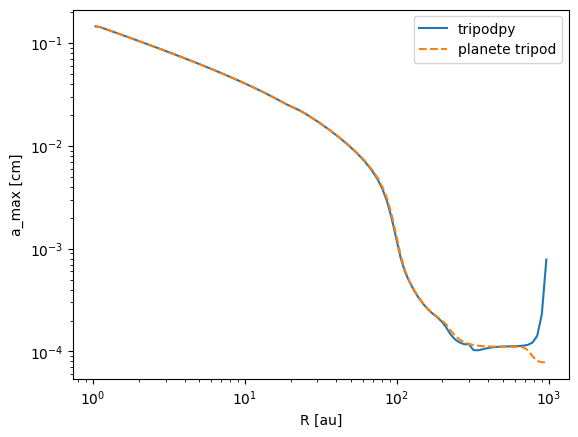

In [56]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.s.max,label="tripodpy")
#plt.loglog(df[1]/c.au,df[4],"--")
plt.loglog(df2[1]/c.au,df2[4],"--",label="planete tripod")
plt.ylabel("a_max [cm]")
plt.xlabel("R [au]")
plt.legend()

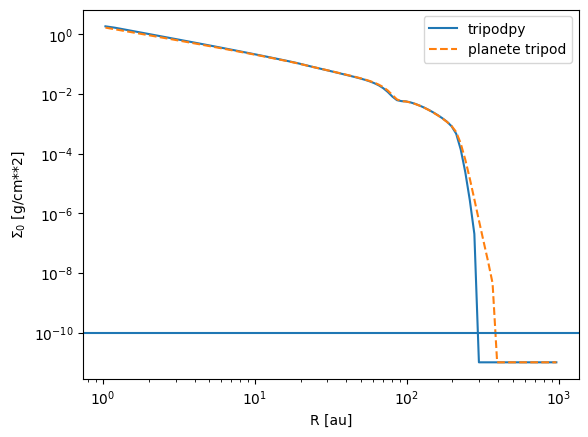

In [57]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,0],label="tripodpy")
plt.loglog(df2[1]/c.au,df2[2],"--",label = "planete tripod")
#plt.loglog(df2[1]/c.au,df[2],"x--")
plt.axhline(1e-10)
plt.ylabel(r"$\Sigma_0$ [g/cm**2]")
plt.xlabel("R [au]")
#plt.ylim(1e-4)
plt.legend()

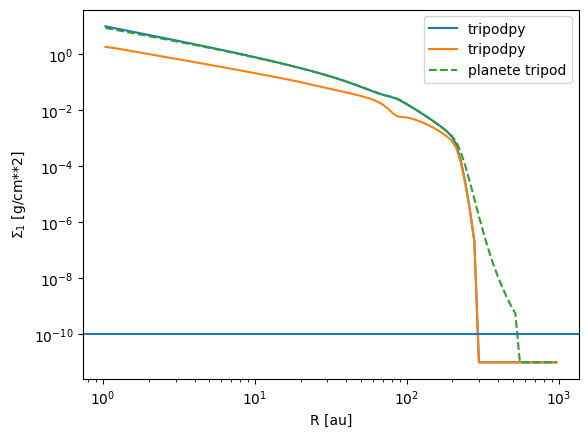

In [ ]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1],label="tripodpy")
plt.loglog(df2[1]/c.au,df2[3],"--",label = "planete tripod")
plt.axhline(1e-10)
plt.ylabel(r"$\Sigma_1$ [g/cm**2]")
plt.xlabel("R [au]")
#plt.ylim(1e-4)
plt.legend()


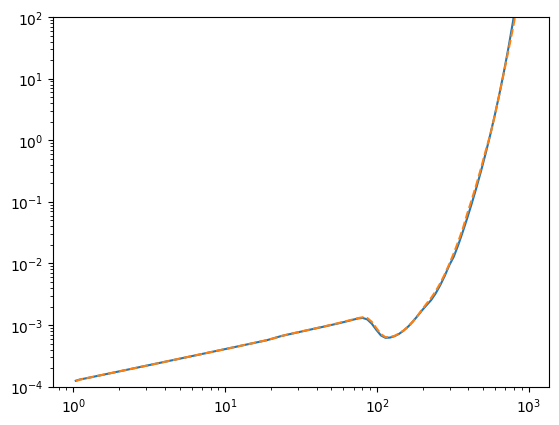

In [64]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.St[:,2],label="tripodpy")
plt.plot(df2[1]/c.au,df2[5],"--",label = "planete tripod")
plt.xscale("log")
plt.ylim(1e-4,1e2)
plt.yscale("log")

(1, 500)

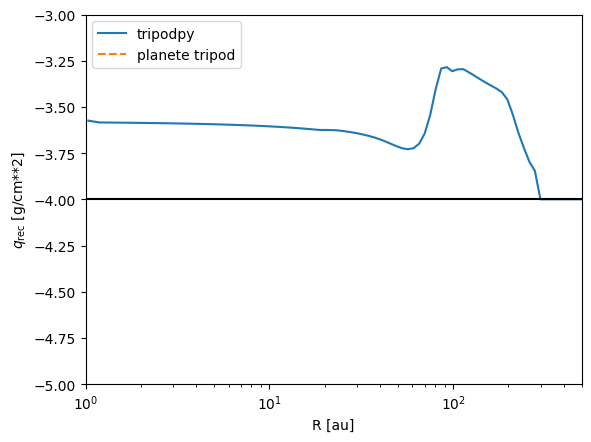

In [59]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.qrec[:],label="tripodpy")
plt.plot(df2[1]/c.au,df2[5],"--",label = "planete tripod")
#plt.plot(df2[1]/c.au,df[5],"--",label = "planete tripod")
plt.ylabel(r"$q_{\rm rec}$ [g/cm**2]")
plt.xlabel("R [au]")
plt.legend()
plt.ylim(-5,-3)
plt.xscale("log")
plt.axhline(-4,color="k")
plt.xlim(1,500)

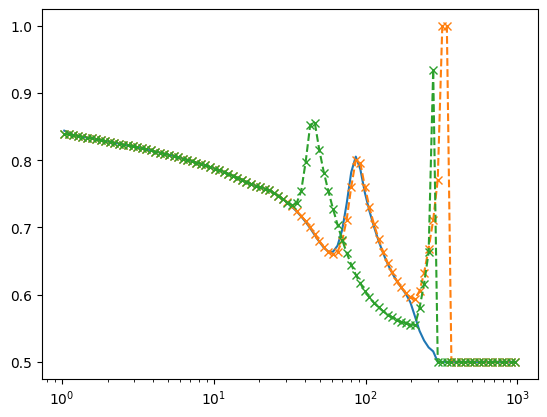

In [22]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1]/sim.dust.Sigma.sum(-1))
plt.loglog(df2[1]/c.au,df2[3]/(df2[3]+df2[2]),"x--")
plt.loglog(df2[1]/c.au,df[3]/(df[3]+df[2]),"x--")
plt.yscale("linear")
#plt.loglog(df2[1]/c.au,df[2],"x--")

In [23]:
df[6][0]/c.year

np.float64(36937.52348959519)

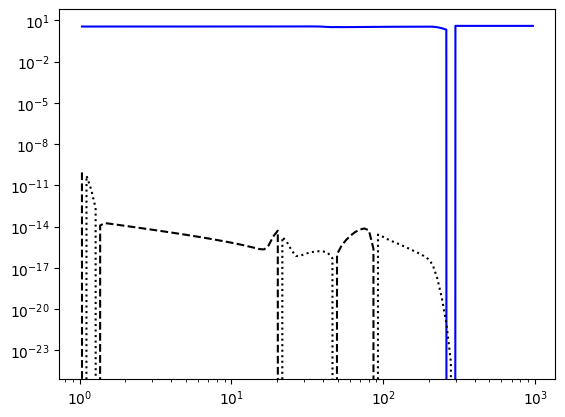

In [24]:
plt.figure()
#plt.plot(sim.grid.r/c.au,sim.dust.s.sdot_coag[:],"-+")

plt.plot(df2[1]/c.au,-df[4],"r--")
plt.plot(df2[1]/c.au,-df[5],"b")
plt.plot(sim.grid.r/c.au,sim.dust.S.coag[:,1],"k:")
plt.plot(sim.grid.r/c.au,sim.dust.S.coag[:,0],"k--")
plt.xscale("log")
plt.yscale("log")
#plt.ylim(1e-4,1e0)

In [25]:
sim.dust.S.toc

Group (Sources)
    - coag: Field (Coagulation sources [g/cm²/s])
    - compo: Field (Sources due to composition changes [g/cm²/s])
    - ext: Field (External sources [g/cm²/s])
    - hyd: Field (Hydrodynamic sources [g/cm²/s])
    - smax_hyd: Field (Total sources [g/cm²/s])
    - tot: Field (Total sources [g/cm²/s])


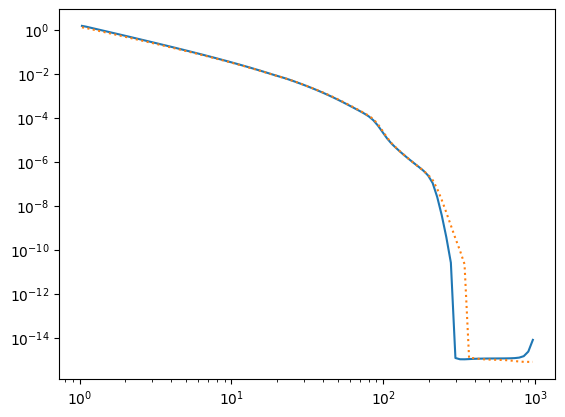

In [26]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.s.max*sim.dust.Sigma[:,1])
#plt.loglog(df[1]/c.au,df[4],"--")
plt.loglog(df2[1]/c.au,df2[4]*df2[3],":")

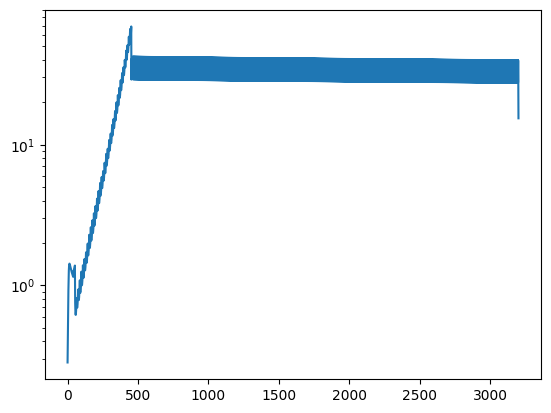

In [27]:
plt.figure()
plt.plot(np.array(list_ts)/c.year)
plt.yscale("log")

In [28]:
sim.dust.delta.rad

[0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001]

In [29]:
sim.dust.backreaction.A,
#sim.dust.backreaction.B

([1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1.],)

In [30]:
sim.gas.v.rad

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]